# Plasma-Dog
# Дообучение YOLO26 для контроля горения плазмы

Детектор состояния горелки по кадру камеры. Задача сведена от классификации
кадра к **детекции объектов** (YOLO26, релиз Ultralytics 01.2026):

- **`flame`** — яркая «клякса» диффузного свечения → пламя **горит** (нарушения нет, класс 0);
- **`electrode`** — видимые электроды в центре → пламя **погасло** (нарушение, класс 1).

Правило приложения: есть `flame` → норма; `flame` нет и виден `electrode` → нарушение.

## Почему детекция, а не классификатор кадра

Исходные метки на уровне сессии (`хорошо`/`плохо`) **разделяются тривиальной
глобальной статистикой** — яркостью и настройками камеры (экспозиция, насыщенность
отличаются между записями). Полнокадровый классификатор выучит *настройки камеры*,
а не физику плазмы. Детекция заставляет модель локализовать `flame`/`electrode` —
это ломает «яркостный» short-cut.

## ⚠️ Честное ограничение данных (прочитать до запуска)

В датасете **3 записи**, состояние внутри каждой **постоянно** (переходов
«горит→погасло» нет), а соседние кадры — почти-дубликаты. То есть на уровне сцен
это **1 пример `flame` + 2 примера `electrode`**. Отсюда:

- любой train/val на кадрах **одних и тех же** сессий даст ~100% — это утечка,
  число бессмысленное;
- класс `flame` представлен **единственной** сессией → независимой валидации для
  него нет;
- честный сигнал даёт только **split по сессиям** (leave-one-session-out) — он и
  используется ниже, с явными оговорками.

Ноутбук — рабочий **proof-of-concept и переиспользуемый пайплайн**. Он станет
боевым, когда добавятся записи (разные условия камеры; сессии с реальным
переходом горит→погасло; больше одной `flame`-сцены). См. раздел 10.

## 0. Окружение (Google Colab, GPU)

`Runtime → Change runtime type → GPU`. Установка Ultralytics + ONNX-стека.

In [1]:
%pip -q install -U ultralytics onnx onnxruntime

In [2]:
from pathlib import Path

import torch
from ultralytics import YOLO
import ultralytics

from google.colab import drive

print("ultralytics", ultralytics.__version__)
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

ultralytics 8.4.99
torch 2.11.0+cu128 | CUDA: True | Tesla T4


## 1. Данные

In [3]:
DATA_ROOT = "/content/drive/MyDrive/Work/Projects/PlasmaDog/data/"

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
DATA_ROOT = Path("/content/drive/MyDrive/Work/Projects/PlasmaDog/data")
# сессия -> метка нарушения (1 = пламя погасло, 0 = пламя горит)
SESSIONS = {
    "2026-06-15_15-05-43-lable-0": 0,   # flame  (клякса)
    "2026-06-15_10-26-28-lable-1": 1,    # electrode
    "2026-06-15_13-12-18-lable-1": 1,    # electrode
}

CLASS_NAMES = ["flame", "electrode"]   # id: 0=flame, 1=electrode
FLAME, ELECTRODE = 0, 1

WORK = Path("/content/plasma_ds")      # сюда соберём YOLO-датасет
SAMPLE_EVERY = 12                      # брать каждый N-й кадр (кадры почти-дубликаты)

assert DATA_ROOT.exists(), f"нет папки {DATA_ROOT} — проверьте загрузку данных"
for s in SESSIONS:
    fr = DATA_ROOT / s / "frames"
    assert fr.exists(), f"нет {fr}"
    print(s, "->", len(list(fr.glob('*.jpg'))), "кадров, метка", SESSIONS[s])

2026-06-15_15-05-43-lable-0 -> 989 кадров, метка 0
2026-06-15_10-26-28-lable-1 -> 988 кадров, метка 1
2026-06-15_13-12-18-lable-1 -> 988 кадров, метка 1


## 2. EDA: демонстрация конфаундинга

Один кадр на сессию + средняя яркость. Видно, что классы разделяются глобальной
яркостью камеры (V у `flame` заметно выше) — это тот short-cut, который детекция
обходит.

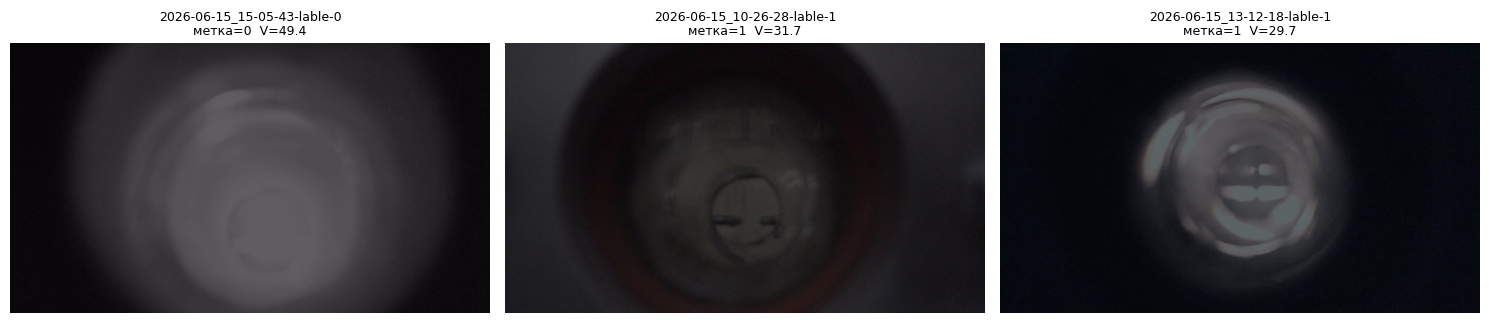

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def first_frame(sess):
    files = sorted((DATA_ROOT / sess / "frames").glob("*.jpg"))
    return cv2.imread(str(files[len(files) // 2]))

fig, ax = plt.subplots(1, len(SESSIONS), figsize=(15, 4))
for i, sess in enumerate(SESSIONS):
    bgr = first_frame(sess)
    v = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)[:, :, 2].mean()
    ax[i].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ax[i].set_title(f"{sess}\nметка={SESSIONS[sess]}  V={v:.1f}", fontsize=9)
    ax[i].axis("off")
plt.tight_layout(); plt.show()

## 3. Полу-авто разметка (bootstrap)

Ручной разметки почти нет:

- **`flame`** — крупная яркая клякса ловится автоматически (grayscale → blur →
  Otsu → крупнейший контур → bbox). Появляется только в `flame`-сессии.
- **`electrode`** — электроды в каждой «плохо»-сессии на **фиксированной** позиции.
  Задаём боксы **один раз на сессию** в `ELECTRODE_BOXES` (координаты полноразмерного
  кадра 1920×1080), скрипт штампует их на все выбранные кадры.

Значения в `ELECTRODE_BOXES` ниже — **стартовые дефолты**, снятые с кадра-эталона.
**Проверьте и поправьте** по монтажу ревью (следующая ячейка).

In [7]:
def detect_flame_box(bgr, min_area_frac=0.03):
    '''Bbox яркой кляксы: gray -> blur -> Otsu -> крупнейший контур. None если нет.'''
    gray = cv2.GaussianBlur(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), (31, 31), 0)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < min_area_frac * bgr.shape[0] * bgr.shape[1]:
        return None
    x, y, w, h = cv2.boundingRect(c)
    return [x, y, x + w, y + h]  # xyxy

# электроды: [x1, y1, x2, y2] в пикселях кадра 1920x1080. ПРОВЕРЬТЕ по ревью ниже.
ELECTRODE_BOXES = {
    "2026-06-15_10-26-28-lable-1": [[810, 650, 930, 745], [1000, 650, 1120, 745]],
    "2026-06-15_13-12-18-lable-1": [[850, 480, 1000, 640], [990, 480, 1140, 640]],
}

def frame_annotations(sess, bgr):
    '''Список (class_id, xyxy) для кадра сессии по её метке.'''
    if SESSIONS[sess] == 0:                     # flame-сессия
        box = detect_flame_box(bgr)
        return [(FLAME, box)] if box else []
    return [(ELECTRODE, b) for b in ELECTRODE_BOXES[sess]]  # electrode-сессия

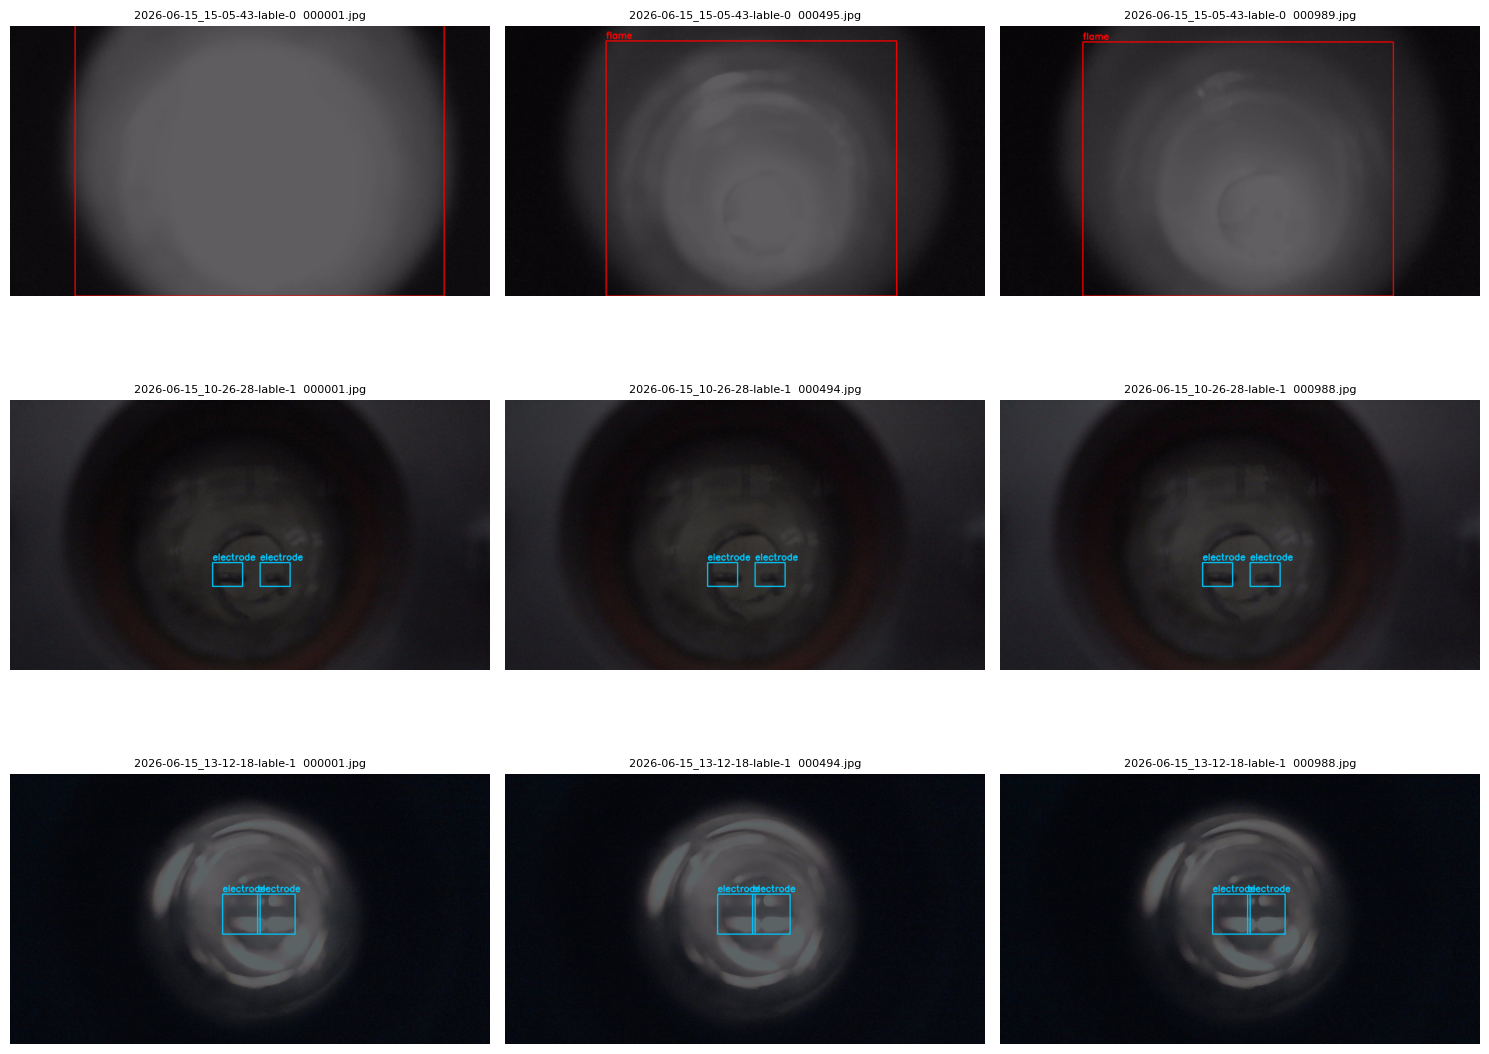

In [8]:
# РЕВЬЮ: боксы на 3 кадрах каждой сессии — визуально проверьте до сборки датасета
fig, ax = plt.subplots(len(SESSIONS), 3, figsize=(15, 4 * len(SESSIONS)))
COLOR = {FLAME: (255, 0, 0), ELECTRODE: (0, 200, 255)}
for r, sess in enumerate(SESSIONS):
    files = sorted((DATA_ROOT / sess / "frames").glob("*.jpg"))
    for c, i in enumerate(np.linspace(0, len(files) - 1, 3).astype(int)):
        bgr = cv2.imread(str(files[i]))
        vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        for cid, box in frame_annotations(sess, bgr):
            x1, y1, x2, y2 = box
            cv2.rectangle(vis, (x1, y1), (x2, y2), COLOR[cid], 4)
            cv2.putText(vis, CLASS_NAMES[cid], (x1, max(0, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, COLOR[cid], 3)
        ax[r, c].imshow(vis); ax[r, c].axis("off")
        ax[r, c].set_title(f"{sess.split()[-1]}  {files[i].name}", fontsize=8)
plt.tight_layout(); plt.show()

## 4. Сборка YOLO-датасета (честный split по сессиям)

Кадры почти-дубликаты → берём каждый `SAMPLE_EVERY`-й. Split — **по сессиям**
(leave-one-session-out), а не случайный:

- **train** = `хорошо` (flame) + одна `плохо` (electrode);
- **val** = вторая `плохо` (electrode) — проверка переноса `electrode` на невиданную сессию.

`flame` есть только в train (единственная сцена) → в val его нет, mAP по `flame`
не считается. Это прямое следствие ограничения данных.

In [9]:
import shutil, yaml

# кто в val (electrode-сессия, удерживаемая для честной проверки переноса)
VAL_SESSION = "2026-06-15_13-12-18-lable-1"

def to_yolo_line(cid, box, w, h):
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2 / w, (y1 + y2) / 2 / h
    bw, bh = (x2 - x1) / w, (y2 - y1) / h
    return f"{cid} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"

# --- оффлайн-аугментация train-кадров (позиционная инвариантность электродов/flame) ---
# электроды в train-сессии стоят в фикс. позиции, на val-сессии — в другой; сдвиг/поворот
# кадров заставляет детектор искать объекты в разных позициях, а не зубрить координаты.
AUG_PER_FRAME = 5           # сколько аугментированных вариантов на каждый train-кадр
AUG_DX = 150                # макс. сдвиг по X, пиксели (+-)
AUG_DY = 150                # макс. сдвиг по Y, пиксели (+-)
AUG_DEG = 8.0               # макс. поворот, градусы (+-)
AUG_SCALE = (0.85, 1.15)    # диапазон масштаба
aug_rng = np.random.default_rng(0)   # детерминированный ГПСЧ для воспроизводимости


def augment_geom(bgr, anns, rng):
    '''Аффинная аугментация кадра и боксов: сдвиг X/Y + поворот + масштаб.

    anns: список (class_id, [x1, y1, x2, y2]) в пикселях.
    Возвращает (aug_bgr, aug_anns): боксы пересчитаны (axis-aligned bbox после
    трансформа), обрезаны по границам кадра; боксы, ушедшие почти за кадр, отброшены.
    '''
    h, w = bgr.shape[:2]
    dx = rng.uniform(-AUG_DX, AUG_DX)
    dy = rng.uniform(-AUG_DY, AUG_DY)
    angle = rng.uniform(-AUG_DEG, AUG_DEG)
    scale = rng.uniform(AUG_SCALE[0], AUG_SCALE[1])
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[0, 2] += dx
    M[1, 2] += dy
    aug_bgr = cv2.warpAffine(bgr, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    kept = []
    for cid, (x1, y1, x2, y2) in anns:
        # 4 угла бокса
        xs = [x1, x2, x2, x1]
        ys = [y1, y1, y2, y2]
        # трансформ углов через аффинную матрицу M
        tx = [M[0, 0] * x + M[0, 1] * y + M[0, 2] for x, y in zip(xs, ys)]
        ty = [M[1, 0] * x + M[1, 1] * y + M[1, 2] for x, y in zip(xs, ys)]
        # axis-aligned bbox повёрнутого бокса
        nx1, nx2 = min(tx), max(tx)
        ny1, ny2 = min(ty), max(ty)
        area_pre = (nx2 - nx1) * (ny2 - ny1)
        # обрезка по границам кадра
        nx1 = float(np.clip(nx1, 0, w))
        nx2 = float(np.clip(nx2, 0, w))
        ny1 = float(np.clip(ny1, 0, h))
        ny2 = float(np.clip(ny2, 0, h))
        area_post = (nx2 - nx1) * (ny2 - ny1)
        # отброс бокса, ушедшего за кадр или схлопнувшегося
        if (nx2 - nx1) < 8 or (ny2 - ny1) < 8 or area_post < 0.35 * area_pre:
            continue
        kept.append((cid, [int(round(nx1)), int(round(ny1)),
                           int(round(nx2)), int(round(ny2))]))
    return aug_bgr, kept


if WORK.exists():
    shutil.rmtree(WORK)
counts = {"train": 0, "val": 0}
per_class = {"train": [0, 0], "val": [0, 0]}
for sess in SESSIONS:
    split = "val" if sess == VAL_SESSION else "train"
    (WORK / "images" / split).mkdir(parents=True, exist_ok=True)
    (WORK / "labels" / split).mkdir(parents=True, exist_ok=True)
    files = sorted((DATA_ROOT / sess / "frames").glob("*.jpg"))[::SAMPLE_EVERY]
    for f in files:
        bgr = cv2.imread(str(f))
        h, w = bgr.shape[:2]
        anns = frame_annotations(sess, bgr)
        if not anns:
            continue
        stem = f"{sess.split()[0]}_{f.stem}"
        cv2.imwrite(str(WORK / "images" / split / f"{stem}.jpg"), bgr)
        (WORK / "labels" / split / f"{stem}.txt").write_text(
            "\n".join(to_yolo_line(c, b, w, h) for c, b in anns))
        counts[split] += 1
        for c, _ in anns:
            per_class[split][c] += 1
        # оффлайн-аугментация ТОЛЬКО train: двигает электроды/flame по кадру,
        # val-сессия остаётся чистой (LOSO не нарушается)
        if split == "train":
            for k in range(AUG_PER_FRAME):
                aug_bgr, aug_anns = augment_geom(bgr, anns, aug_rng)
                if not aug_anns:
                    continue                      # все боксы ушли за кадр -> пропуск варианта
                aug_stem = f"{stem}_aug{k}"
                cv2.imwrite(str(WORK / "images" / split / f"{aug_stem}.jpg"), aug_bgr)
                (WORK / "labels" / split / f"{aug_stem}.txt").write_text(
                    "\n".join(to_yolo_line(c, b, w, h) for c, b in aug_anns))
                counts[split] += 1
                for c, _ in aug_anns:
                    per_class[split][c] += 1

data_yaml = WORK / "plasma.yaml"
data_yaml.write_text(yaml.safe_dump({
    "path": str(WORK), "train": "images/train", "val": "images/val",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}, allow_unicode=True))

print("кадров:", counts)
print("боксов train  [flame, electrode]:", per_class["train"])
print("боксов val    [flame, electrode]:", per_class["val"])
print("\n⚠️ flame в val отсутствует (единственная сцена) — mAP по flame не валиден.")
print(data_yaml.read_text())

кадров: {'train': 996, 'val': 83}
боксов train  [flame, electrode]: [498, 996]
боксов val    [flame, electrode]: [0, 166]

⚠️ flame в val отсутствует (единственная сцена) — mAP по flame не валиден.
names:
  0: flame
  1: electrode
path: /content/plasma_ds
train: images/train
val: images/val



## 4b. Ревью аугментации — проверить, что боксы едут вместе с картинкой

Визуальная проверка `augment_geom`: берём по кадру из каждой train-сессии (flame
и electrode), прогоняем аугментацию несколько раз и рисуем пересчитанные боксы
поверх `aug_bgr`. Боксы должны накрывать объекты после сдвига/поворота/масштаба —
это подтверждает корректность bbox-математики (трансформ углов -> axis-aligned bbox -> обрезка по кадру).

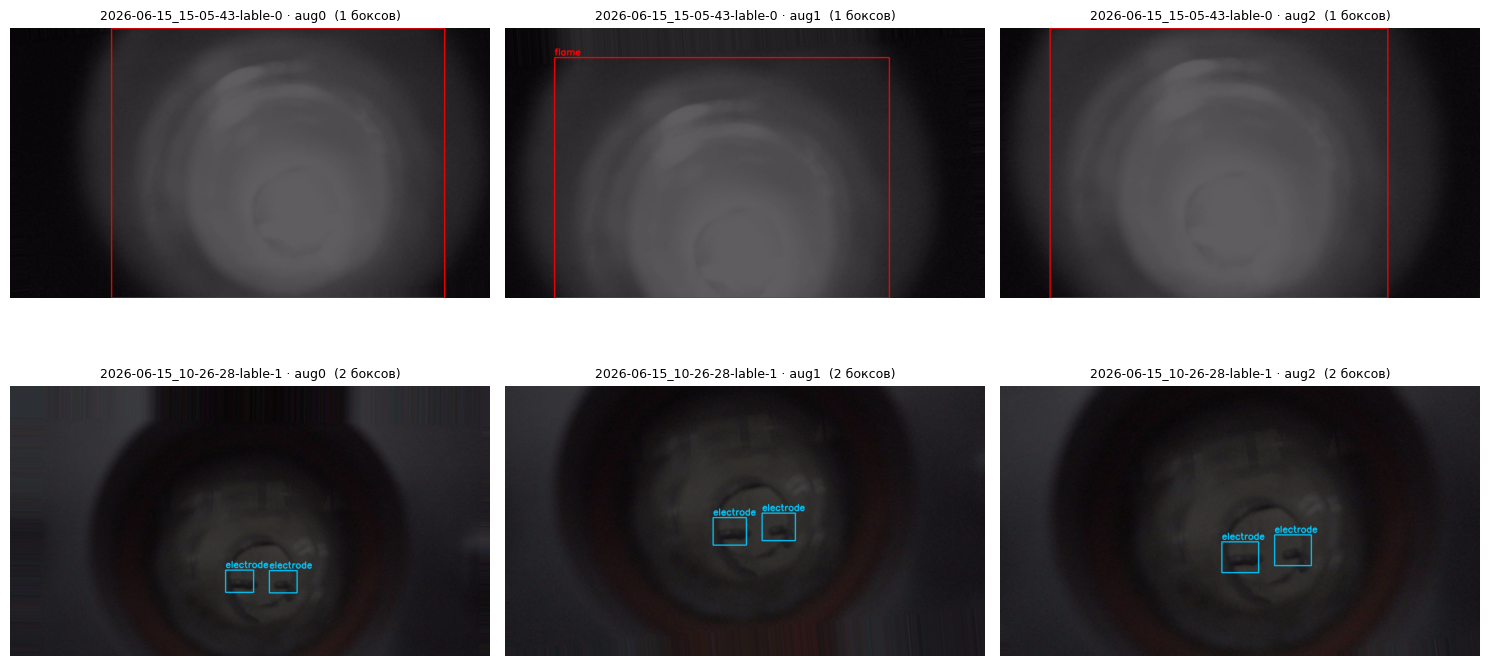

In [10]:
# ревью оффлайн-аугментации: боксы должны накрывать объекты после сдвига/поворота
TRAIN_SESS_FOR_REVIEW = [s for s in SESSIONS if s != VAL_SESSION]
REVIEW_FRAMES = {}
for sess in TRAIN_SESS_FOR_REVIEW:
    fs = sorted((DATA_ROOT / sess / "frames").glob("*.jpg"))
    bgr = cv2.imread(str(fs[len(fs) // 2]))
    REVIEW_FRAMES[sess] = (bgr, frame_annotations(sess, bgr))

# цвета как в разделе 3: flame красный, electrode жёлто-голубой
REVIEW_COLOR = {FLAME: (255, 0, 0), ELECTRODE: (0, 200, 255)}
review_rng = np.random.default_rng(42)

# сетка: 2 строки (flame, electrode) x 3 колонки (3 аугментации)
fig, ax = plt.subplots(len(TRAIN_SESS_FOR_REVIEW), 3, figsize=(15, 4 * len(TRAIN_SESS_FOR_REVIEW)))
for r, sess in enumerate(TRAIN_SESS_FOR_REVIEW):
    bgr, anns = REVIEW_FRAMES[sess]
    for c in range(3):
        aug_bgr, aug_anns = augment_geom(bgr, anns, review_rng)
        vis = cv2.cvtColor(aug_bgr, cv2.COLOR_BGR2RGB).copy()
        for cid, (x1, y1, x2, y2) in aug_anns:
            cv2.rectangle(vis, (x1, y1), (x2, y2), REVIEW_COLOR[cid], 4)
            cv2.putText(vis, CLASS_NAMES[cid], (x1, max(0, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, REVIEW_COLOR[cid], 3)
        ax[r, c].imshow(vis); ax[r, c].axis("off")
        tag = sess.split()[-1]
        ax[r, c].set_title(f"{tag} · aug{c}  ({len(aug_anns)} боксов)", fontsize=9)
plt.tight_layout(); plt.show()

## 5. Обучение YOLO26

Базовая модель — **`yolo26n`** (nano): быстрая на CPU/ONNX, лучший выбор для
десктопа без GPU.

**Онлайн-аугментация — МЯГКАЯ** (откат агрессивного усиления, вызвавшего коллапс
x25 и падение mAP в 11 раз). Оставлен только фотометрический jitter яркости и
оттенка (`hsv_v`, `hsv_h`, `hsv_s`) — он ломает яркостный short-cut — плюс
горизонтальный флип (`fliplr`). Геометрическая online-аугментация сведена к минимуму
(`translate=0.05`, `scale=0.3`, `mosaic=0.0`, без `degrees`/`perspective`):
позиционное и поворотное разнообразие электродов/flame теперь даётся
**оффлайн-аугментацией train-кадров в разделе 4** (сдвиг X/Y + поворот + масштаб),
что контролируемее, чем стохастический онлайн-трансформ.

In [11]:
model = YOLO("yolo26n.pt")

results = model.train(
    data=str(data_yaml),
    epochs=80,
    imgsz=640,
    batch=16,
    patience=20,
    seed=0,
    project="/content/runs",
    name="plasma_yolo26n",
    # online-аугментация МЯГКАЯ: фотометрический jitter (hsv_* против яркостного
    # short-cut) + горизонтальный флип. Позиционное/поворотное разнообразие даётся
    # ОФФЛАЙН-аугментацией train-кадров в разделе 4 (сдвиг X/Y + поворот).
    hsv_v=0.5,            # фотометрический jitter яркости (V) против яркостного short-cut
    hsv_h=0.20,
    hsv_s=0.7,
    fliplr=0.5,
    flipud=0.0,
    translate=0.05,       # геометрия оффлайн -> онлайн-сдвиг почти выключен
    scale=0.3,            # геометрия оффлайн -> онлайн-масштаб мягкий
    mosaic=0.0,           # mosaic выключен: позиции/масштабы уже разнообразит раздел 4
)
BEST = Path(results.save_dir) / "weights" / "best.pt"
print("лучшие веса:", BEST)

Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plasma_ds/plasma.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.2, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=plasma_yolo26n-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

## 6. Валидация (с оговорками)

`model.val()` считает mAP на удержанной `плохо`-сессии — это перенос `electrode`
на невиданную запись. Помните: `flame` не валидируется (одна сцена), а близость
кадров внутри сессии завышает метрики. Ниже — ещё и визуальная проверка предсказаний.

Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3450.1±950.7 MB/s, size: 182.9 KB)
val: Scanning /content/plasma_ds/labels/val.cache... 83 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 83/83 31.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.2it/s 2.7s0.5s
                   all         83        166     0.0131      0.663      0.369     0.0626
             electrode         83        166     0.0131      0.663      0.369     0.0626
Speed: 5.3ms preprocess, 7.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP50: 0.369 | mAP50-95: 0.063


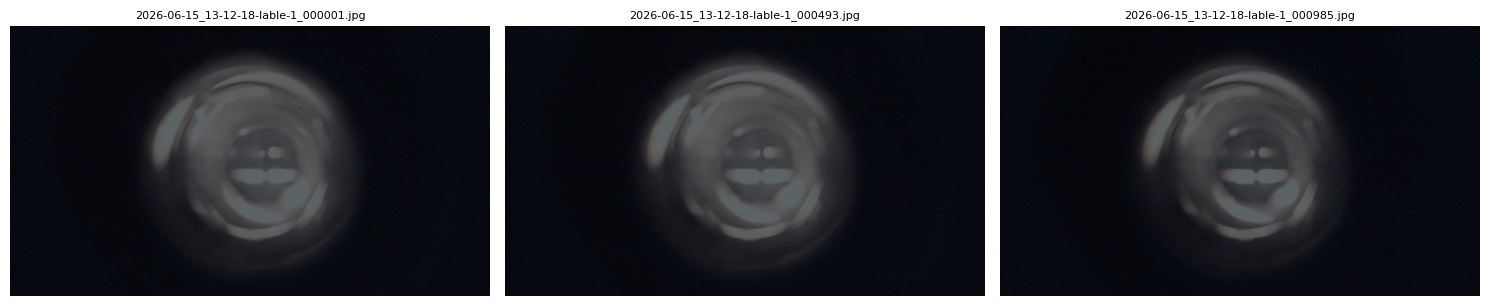

In [12]:
best = YOLO(str(BEST))
metrics = best.val(data=str(data_yaml), imgsz=640)
print("mAP50:", round(float(metrics.box.map50), 3), "| mAP50-95:", round(float(metrics.box.map), 3))

# визуальная проверка на кадрах val-сессии
val_imgs = sorted((WORK / "images" / "val").glob("*.jpg"))
sample = [val_imgs[i] for i in np.linspace(0, len(val_imgs) - 1, 3).astype(int)]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, p in zip(ax, sample):
    r = best.predict(str(p), imgsz=640, conf=0.35, verbose=False)[0]
    ax_img = r.plot()  # BGR с боксами
    a.imshow(cv2.cvtColor(ax_img, cv2.COLOR_BGR2RGB)); a.axis("off"); a.set_title(p.name, fontsize=8)
plt.tight_layout(); plt.show()

## 7. Правило принятия решения (мост к приложению)

Из детекций → состояние: `0` норма (пламя горит), `1` нарушение (пламя погасло),
`-1` неопределённо. Приоритет у `flame`: если клякса есть — пламя горит.

In [13]:
def decide_state(dets, conf=0.35, min_electrodes=1):
    '''dets: список (class_id, confidence). -> 0 норма / 1 нарушение / -1 unknown.'''
    flame = [d for d in dets if d[0] == FLAME and d[1] >= conf]
    elec = [d for d in dets if d[0] == ELECTRODE and d[1] >= conf]
    if flame:
        return 0                       # пламя горит -> нарушения нет
    if len(elec) >= min_electrodes:
        return 1                       # электроды видны, кляксы нет -> нарушение
    return -1                          # неопределённо

STATE_TXT = {0: "ПЛАМЯ ГОРИТ (норма)", 1: "ПОГАСЛО (нарушение)", -1: "неопределённо"}

# проверка: по кадру-эталону каждой сессии предсказанное состояние vs метка
for sess in SESSIONS:
    files = sorted((DATA_ROOT / sess / "frames").glob("*.jpg"))
    p = files[len(files) // 2]
    r = best.predict(str(p), imgsz=640, conf=0.35, verbose=False)[0]
    dets = [(int(c), float(cf)) for c, cf in zip(r.boxes.cls, r.boxes.conf)]
    st = decide_state(dets)
    print(f"{sess:34s} метка={SESSIONS[sess]}  ->  {st} · {STATE_TXT[st]}")

2026-06-15_15-05-43-lable-0        метка=0  ->  -1 · неопределённо
2026-06-15_10-26-28-lable-1        метка=1  ->  1 · ПОГАСЛО (нарушение)
2026-06-15_13-12-18-lable-1        метка=1  ->  -1 · неопределённо


## 8. Экспорт в ONNX (для onnxruntime)

YOLO26 экспортируется как **end-to-end (NMS-free)**: выход `(1, 300, 6)` =
`[x1, y1, x2, y2, conf, class_id]`. Постобработка — только фильтр по confidence.
Имена классов и `imgsz` зашиваются в метаданные ONNX.

In [14]:
onnx_path = best.export(format="onnx", imgsz=640, simplify=True, dynamic=False)
print("ONNX:", onnx_path)

# верификация через onnxruntime
import onnxruntime as ort

sess_ort = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
meta = sess_ort.get_modelmeta().custom_metadata_map
print("вход :", sess_ort.get_inputs()[0].name, sess_ort.get_inputs()[0].shape)
print("выход:", sess_ort.get_outputs()[0].name, sess_ort.get_outputs()[0].shape)
print("names в метаданных:", meta.get("names"))

Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/plasma_yolo26n-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 1.7s, saved as '/content/runs/plasma_yolo26n-3/weights/best.onnx' (9.4 MB)

Export complete (2.1s)
Results saved to /content/runs/plasma_yolo26n-3/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/plasma_yolo26n-3/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/plasma_yolo26n-3/weights/best.onnx imgsz=640 data=/content/plasma_ds/plasma.yaml  
Visualize:       https://netron.app
ONNX: /content/runs/plasma_yolo26n-3/weights/best.onnx
вход : images [1, 3, 640, 640]
выход: output0 [1, 300, 6]
names в метаданных: {0: 'flame', 1: 'electrode'}


## 9. Референс-инференс на onnxruntime

Самодостаточный код **без ultralytics/torch** — ровно то, что кладётся в
десктоп-приложение (`opencv` + `numpy` + `onnxruntime`). Обрабатывает и end-to-end
выход `(1,300,6)`, и «сырой» `(1, 4+nc, N)` (ручной NMS) — на случай иной сборки.

In [15]:
def letterbox(bgr, new=640, color=114):
    h, w = bgr.shape[:2]
    r = min(new / h, new / w)
    nh, nw = round(h * r), round(w * r)
    pad_h, pad_w = (new - nh) // 2, (new - nw) // 2
    canvas = np.full((new, new, 3), color, np.uint8)
    canvas[pad_h:pad_h + nh, pad_w:pad_w + nw] = cv2.resize(bgr, (nw, nh))
    return canvas, r, pad_w, pad_h

def _nms(boxes, scores, iou_thr=0.5):
    idx = scores.argsort()[::-1]
    keep = []
    while idx.size:
        i = idx[0]; keep.append(i)
        if idx.size == 1:
            break
        xx1 = np.maximum(boxes[i, 0], boxes[idx[1:], 0])
        yy1 = np.maximum(boxes[i, 1], boxes[idx[1:], 1])
        xx2 = np.minimum(boxes[i, 2], boxes[idx[1:], 2])
        yy2 = np.minimum(boxes[i, 3], boxes[idx[1:], 3])
        inter = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        area_i = (boxes[i, 2] - boxes[i, 0]) * (boxes[i, 3] - boxes[i, 1])
        area_r = (boxes[idx[1:], 2] - boxes[idx[1:], 0]) * (boxes[idx[1:], 3] - boxes[idx[1:], 1])
        iou = inter / (area_i + area_r - inter + 1e-9)
        idx = idx[1:][iou < iou_thr]
    return keep

def infer_onnx(bgr, ort_session, imgsz=640, conf=0.35):
    '''-> список (class_id, confidence, [x1,y1,x2,y2]) в координатах исходного кадра.'''
    img, r, pad_w, pad_h = letterbox(bgr, imgsz)
    blob = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32).transpose(2, 0, 1)[None] / 255.0
    out = ort_session.run(None, {ort_session.get_inputs()[0].name: blob})[0]
    out = np.squeeze(out, 0) if out.ndim == 3 else out

    dets = []
    if out.shape[-1] == 6:                       # end-to-end (1,300,6)
        for x1, y1, x2, y2, cf, cid in out:
            if cf >= conf:
                dets.append((int(cid), float(cf), [x1, y1, x2, y2]))
    else:                                        # сырой (4+nc, N) -> ручной NMS
        pred = out.T if out.shape[0] < out.shape[1] else out
        boxes_xywh, cls_scores = pred[:, :4], pred[:, 4:]
        cid = cls_scores.argmax(1)
        cf = cls_scores.max(1)
        m = cf >= conf
        boxes_xywh, cid, cf = boxes_xywh[m], cid[m], cf[m]
        xy = np.empty_like(boxes_xywh)
        xy[:, 0] = boxes_xywh[:, 0] - boxes_xywh[:, 2] / 2
        xy[:, 1] = boxes_xywh[:, 1] - boxes_xywh[:, 3] / 2
        xy[:, 2] = boxes_xywh[:, 0] + boxes_xywh[:, 2] / 2
        xy[:, 3] = boxes_xywh[:, 1] + boxes_xywh[:, 3] / 2
        for i in _nms(xy, cf):
            dets.append((int(cid[i]), float(cf[i]), list(xy[i])))

    # снять letterbox -> координаты исходного кадра
    res = []
    for c, s, (x1, y1, x2, y2) in dets:
        res.append((c, s, [(x1 - pad_w) / r, (y1 - pad_h) / r,
                           (x2 - pad_w) / r, (y2 - pad_h) / r]))
    return res

# проверка эквивалентности onnxruntime vs ultralytics на одном кадре
p = sorted((WORK / "images" / "val").glob("*.jpg"))[0]
bgr = cv2.imread(str(p))
ort_dets = infer_onnx(bgr, sess_ort)
print("onnxruntime детекции (class, conf):", [(CLASS_NAMES[c], round(s, 2)) for c, s, _ in ort_dets])
print("решение:", STATE_TXT[decide_state([(c, s) for c, s, _ in ort_dets])])

onnxruntime детекции (class, conf): []
решение: неопределённо


## 10. Интеграция в plasma-dog (PyQt6) и следующие шаги

### Куда подключать
Поток захвата `src/plasma_dog/camera/capture.py` эмитит
`CaptureThread.frame_ready(numpy_BGR, timestamp)`. Инференс вешается на этот сигнал.
Рекомендуемая структура (новый модуль, изолирует ML от UI):

```
src/plasma_dog/inference/
    __init__.py
    flame_detector.py    # класс-обёртка над onnxruntime (letterbox/infer/decide_state из разделов 7,9)
```

Скелет обёртки (переносит функции разделов 7 и 9, зависимости — только
`opencv`+`numpy`+`onnxruntime`, без torch):

```python
class FlameDetector:
    def __init__(self, onnx_path: str, conf: float = 0.35) -> None:
        self._sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
        names = self._sess.get_modelmeta().custom_metadata_map.get("names", "")
        self._conf = conf

    def infer(self, bgr) -> int:          # -> 0 норма / 1 нарушение / -1 unknown
        dets = infer_onnx(bgr, self._sess, conf=self._conf)
        return decide_state([(c, s) for c, s, _ in dets], conf=self._conf)
```

Подключение в `MainWindow` (эскиз): подписаться на `frame_ready`, **троттлить**
(инференс раз в ~0.5–1 с, не на каждый кадр), результат выводить в `RecordingStatusBar`
(«ПЛАМЯ ГОРИТ» / «ПОГАСЛО»). Зависимость `onnxruntime` добавить в `pyproject.toml`,
`best.onnx` класть в ресурсы приложения.

### Что нужно собрать, чтобы модель стала боевой
Текущий результат — PoC на 3 сценах. Для продакшена нужны данные, а не тюнинг:

1. **Больше записей** при разных настройках камеры (экспозиция, WB, gain) — чтобы
   `flame`/`electrode` перестали коррелировать с яркостью конкретной записи.
2. **Сессии с реальным переходом** горит→погасло внутри одной записи — тогда
   целевой признак развязан от настроек камеры и появляется честный val.
3. **Больше одной `flame`-сцены** — сейчас класс `flame` не валидируется вовсе.
4. После сбора — повторить этот ноутбук: bootstrap-разметка масштабируется, split
   по сессиям станет полноценным LOSO.